In [19]:
# ==================== IMPORT LIBRARIES ====================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("✓ Libraries loaded successfully!")
print(f"✓ TensorFlow version: {tf.__version__}")
print(f"✓ OpenCV version: {cv2.__version__}")
print("="*70)

✓ Libraries loaded successfully!
✓ TensorFlow version: 2.18.0
✓ OpenCV version: 4.12.0


In [20]:
# ==================== SETUP DATASET ====================
print("="*70)
print("SETUP DATASET - Cataract Detection")
print("="*70)

# Dataset path
data_dir = "dataset"  # Sesuaikan dengan lokasi dataset kamu

# Function untuk scan dan filter data
def create_filtered_dataframe(data_dir, target_classes=['cataract', 'normal']):
    """
    Scan dataset dan ambil hanya class Cataract dan Normal
    """
    filepaths = []
    labels = []
    
    print("\nScanning dataset folders...")
    
    # Scan semua folder di data_dir
    all_folders = os.listdir(data_dir)
    print(f"Found folders: {all_folders}")
    
    # Filter hanya folder yang kita mau (case-insensitive)
    target_folders = []
    for folder in all_folders:
        folder_lower = folder.lower()
        if any(target in folder_lower for target in target_classes):
            target_folders.append(folder)
    
    print(f"\nFiltered to target classes: {target_folders}")
    
    # Collect filepaths dan labels
    for folder in target_folders:
        folder_path = os.path.join(data_dir, folder)
        
        if os.path.isdir(folder_path):
            files = os.listdir(folder_path)
            print(f"\n📁 {folder}: {len(files)} images")
            
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    filepath = os.path.join(folder_path, file)
                    filepaths.append(filepath)
                    
                    # Standardize label name
                    if 'cataract' in folder.lower():
                        labels.append('Cataract')
                    else:
                        labels.append('Normal')
    
    # Create DataFrame
    df = pd.DataFrame({
        'filepaths': filepaths,
        'labels': labels
    })
    
    return df

# Create dataframe
print("\nCreating dataset dataframe...")
df = create_filtered_dataframe(data_dir)

print("\n" + "="*70)
print("📊 DATASET SUMMARY")
print("="*70)
print(f"Total images: {len(df)}")
print(f"\nClass distribution:")
print(df['labels'].value_counts())
print("\nSample data:")
print(df.head(10))
print("="*70)

SETUP DATASET - Cataract Detection

Creating dataset dataframe...

Scanning dataset folders...
Found folders: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

Filtered to target classes: ['cataract', 'normal']

📁 cataract: 1038 images

📁 normal: 1074 images

📊 DATASET SUMMARY
Total images: 2112

Class distribution:
labels
Normal      1074
Cataract    1038
Name: count, dtype: int64

Sample data:
                         filepaths    labels
0      dataset\cataract\0_left.jpg  Cataract
1    dataset\cataract\103_left.jpg  Cataract
2  dataset\cataract\1062_right.jpg  Cataract
3   dataset\cataract\1083_left.jpg  Cataract
4  dataset\cataract\1084_right.jpg  Cataract
5   dataset\cataract\1102_left.jpg  Cataract
6  dataset\cataract\1102_right.jpg  Cataract
7   dataset\cataract\1115_left.jpg  Cataract
8  dataset\cataract\1126_right.jpg  Cataract
9   dataset\cataract\112_right.jpg  Cataract


In [21]:
# ==================== SPLIT DATASET ====================
print("="*70)
print("SPLITTING DATASET")
print("="*70)

# Split stratified (pastikan proporsi class tetap sama)
# Split 1: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df, 
    train_size=0.8, 
    shuffle=True, 
    random_state=42,
    stratify=df['labels']  # Pastikan proporsi class sama
)

# Split 2: 50% val, 50% test dari temp (jadi masing-masing 10% dari total)
val_df, test_df = train_test_split(
    temp_df, 
    train_size=0.5, 
    shuffle=True, 
    random_state=42,
    stratify=temp_df['labels']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n📊 SPLIT SUMMARY")
print("="*70)
print(f"Total dataset: {len(df)} images")
print(f"\nTrain set: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(train_df['labels'].value_counts())
print(f"\nValidation set: {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(val_df['labels'].value_counts())
print(f"\nTest set: {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")
print(test_df['labels'].value_counts())
print("="*70)

# Verifikasi tidak ada data leak
print("\n🔍 Verifikasi No Data Leakage...")
train_files = set(train_df['filepaths'])
val_files = set(val_df['filepaths'])
test_files = set(test_df['filepaths'])

overlap_train_val = train_files.intersection(val_files)
overlap_train_test = train_files.intersection(test_files)
overlap_val_test = val_files.intersection(test_files)

if len(overlap_train_val) == 0 and len(overlap_train_test) == 0 and len(overlap_val_test) == 0:
    print("✓ No data leakage detected! All splits are independent.")
else:
    print("⚠ WARNING: Data leakage detected!")

print("="*70)

SPLITTING DATASET

📊 SPLIT SUMMARY
Total dataset: 2112 images

Train set: 1689 images (80.0%)
labels
Normal      859
Cataract    830
Name: count, dtype: int64

Validation set: 211 images (10.0%)
labels
Normal      107
Cataract    104
Name: count, dtype: int64

Test set: 212 images (10.0%)
labels
Normal      108
Cataract    104
Name: count, dtype: int64

🔍 Verifikasi No Data Leakage...
✓ No data leakage detected! All splits are independent.


 PREPROCESSING - Fast & Effective

🧪 Testing preprocessing...


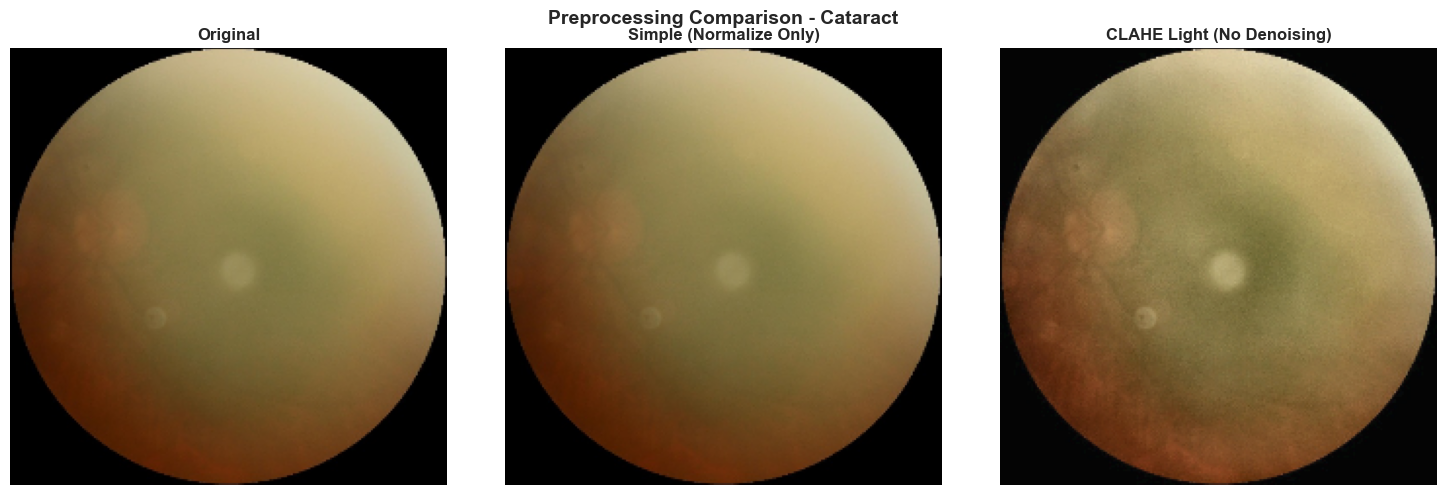


💡 PILIHAN PREPROCESSING:
1. Simple (Normalize Only)    → Paling cepat, natural
2. CLAHE Light (No Denoising)  → Enhance contrast, masih cepat

Kita akan coba keduanya!


In [31]:
# ==================== PREPROCESSING ====================
print("="*70)
print(" PREPROCESSING - Fast & Effective")
print("="*70)

def preprocess_simple(img):
    """
    Simple preprocessing tanpa heavy computation
    - Input: RGB image (0-255)  
    - Output: Normalized RGB (0-1)
    """
    # Normalize aja ke 0-1
    return img.astype(np.float32) / 255.0

def preprocess_clahe_light(img):
    """
    CLAHE ringan tanpa denoising
    - Input: RGB image (0-255)
    - Output: Enhanced RGB (0-1)
    """
    # Convert ke uint8
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    
    # CLAHE langsung tanpa denoising
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Normalize
    return enhanced.astype(np.float32) / 255.0

# Test kedua preprocessing
print("\n🧪 Testing preprocessing...")

sample_path = train_df.iloc[0]['filepaths']
sample_label = train_df.iloc[0]['labels']

img_original = cv2.imread(sample_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_original_resized = cv2.resize(img_original, (224, 224))

img_simple = preprocess_simple(img_original_resized.copy())
img_clahe_light = preprocess_clahe_light(img_original_resized.copy())

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Preprocessing Comparison - {sample_label}', fontsize=14, fontweight='bold')

axes[0].imshow(img_original_resized)
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_simple)
axes[1].set_title('Simple (Normalize Only)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(img_clahe_light)
axes[2].set_title('CLAHE Light (No Denoising)', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("💡 PILIHAN PREPROCESSING:")
print("="*70)
print("1. Simple (Normalize Only)    → Paling cepat, natural")
print("2. CLAHE Light (No Denoising)  → Enhance contrast, masih cepat")
print("\nKita akan coba keduanya!")
print("="*70)

In [32]:
# ==================== DATA GENERATORS ====================
print("="*70)
print(" DATA GENERATORS - Simple Preprocessing")
print("="*70)

# Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# PILIHAN: Kita coba SIMPLE dulu (normalize only)
print("\n📌 Using: Simple Preprocessing (Normalize Only)")
print("   → Fastest, most stable for initial training")

# Data Augmentation untuk Training
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Simple normalization
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0
)

# Validation & Test: Hanya rescale
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("\n✓ Training: Rescale + Medical-friendly augmentation")
print("✓ Val/Test: Rescale only")

# Create generators
print("\n" + "="*70)
print("Creating new data generators...")
print("="*70)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n" + "="*70)
print("📊 NEW GENERATOR SUMMARY")
print("="*70)
print(f"Training samples: {train_gen.n}")
print(f"Validation samples: {val_gen.n}")
print(f"Test samples: {test_gen.n}")
print(f"Class indices: {train_gen.class_indices}")
print(f"Batches per epoch: {len(train_gen)}")
print("="*70)

 DATA GENERATORS - Simple Preprocessing

📌 Using: Simple Preprocessing (Normalize Only)
   → Fastest, most stable for initial training

✓ Training: Rescale + Medical-friendly augmentation
✓ Val/Test: Rescale only

Creating new data generators...
Found 1689 validated image filenames belonging to 2 classes.
Found 211 validated image filenames belonging to 2 classes.
Found 212 validated image filenames belonging to 2 classes.

📊 NEW GENERATOR SUMMARY
Training samples: 1689
Validation samples: 211
Test samples: 212
Class indices: {'Cataract': 0, 'Normal': 1}
Batches per epoch: 53


In [33]:
# ==================== MODEL ====================
print("="*70)
print(" MODEL - Better Strategy")
print("="*70)

# Clear previous model
import gc
del model
gc.collect()
tf.keras.backend.clear_session()

print("✓ Previous model cleared\n")

# Load fresh EfficientNetB0
print("🔧 Loading fresh EfficientNetB0...")
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Strategy: Unfreeze sebagian layer (Fine-tune dari awal!)
# Freeze hanya bottom layers, unfreeze top layers
base_model.trainable = True

# Freeze first 100 layers (low-level features)
for layer in base_model.layers[:100]:
    layer.trainable = False

# Unfreeze sisanya (high-level features)
for layer in base_model.layers[100:]:
    layer.trainable = True

print(f"✓ Base model loaded")
print(f"  Total layers: {len(base_model.layers)}")
print(f"  Frozen layers: 100")
print(f"  Trainable layers: {len(base_model.layers) - 100}")

# Build simpler head (lebih mudah dilatih)
print("\n🏗️ Building simplified architecture...")

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

print("\n" + "="*70)
print("📊 NEW MODEL ARCHITECTURE")
print("="*70)
model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n" + "="*70)
print("📈 PARAMETER COUNT")
print("="*70)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")
print(f"Trainable %: {trainable_params/total_params*100:.1f}%")
print("="*70)

# Compile with LOWER learning rate
print("\n⚙️ Compiling model...")
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # LOWER LR!
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

print("✓ Model compiled!")
print(f"  Learning Rate: 0.0001 (10x lebih kecil!)")
print(f"  Strategy: Partial fine-tuning dari awal")

print("\n" + "="*70)
print("💡 NEW STRATEGY:")
print("="*70)
print("✓ Simpler head (1 dense layer vs 3)")
print("✓ Partial unfreezing (100 frozen, 138 trainable)")
print("✓ Lower LR (0.0001)")
print("✓ No heavy preprocessing")
print("→ Should converge much faster!")
print("="*70)

 MODEL - Better Strategy

✓ Previous model cleared

🔧 Loading fresh EfficientNetB0...
✓ Base model loaded
  Total layers: 238
  Frozen layers: 100
  Trainable layers: 138

🏗️ Building simplified architecture...

📊 NEW MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 4,004,445 (15.28 MB)

 Non-trainable params: 209,223 (817.28 KB)


📈 PARAMETER COUNT
Total parameters: 4,213,668
Trainable parameters: 4,004,445
Non-trainable parameters: 209,223
Trainable %: 95.0%

⚙️ Compiling model...
✓ Model compiled!
  Learning Rate: 0.0001 (10x lebih kecil!)
  Strategy: Partial fine-tuning dari awal

💡 NEW STRATEGY:
✓ Simpler head (1 dense layer vs 3)
✓ Partial unfreezing (100 frozen, 138 trainable)
✓ Lower LR (0.0001)
✓ No heavy preprocessing
→ Should converge much faster!


SETUP CALLBACKS & START TRAINING
✓ Callbacks ready
  • EarlyStopping: patience=10
  • ReduceLR: patience=5
  • Checkpoint: save best model

🚀 STARTING TRAINING - Improved Strategy
Epochs: 30
Learning Rate: 0.0001
Strategy: Partial fine-tuning
Preprocessing: Simple (normalize only)

Starting training...
----------------------------------------------------------------------
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5836 - auc: 0.6149 - loss: 0.6686 - precision: 0.5921 - recall: 0.5957
Epoch 1: val_accuracy improved from -inf to 0.49289, saving model to best_cataract_model_v2.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.5840 - auc: 0.6155 - loss: 0.6683 - precision: 0.5924 - recall: 0.5961 - val_accuracy: 0.4929 - val_auc: 0.5000 - val_loss: 0.6938 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6529 - auc: 0.7229 - loss: 0.5894 - precision: 0.6367 - recall: 

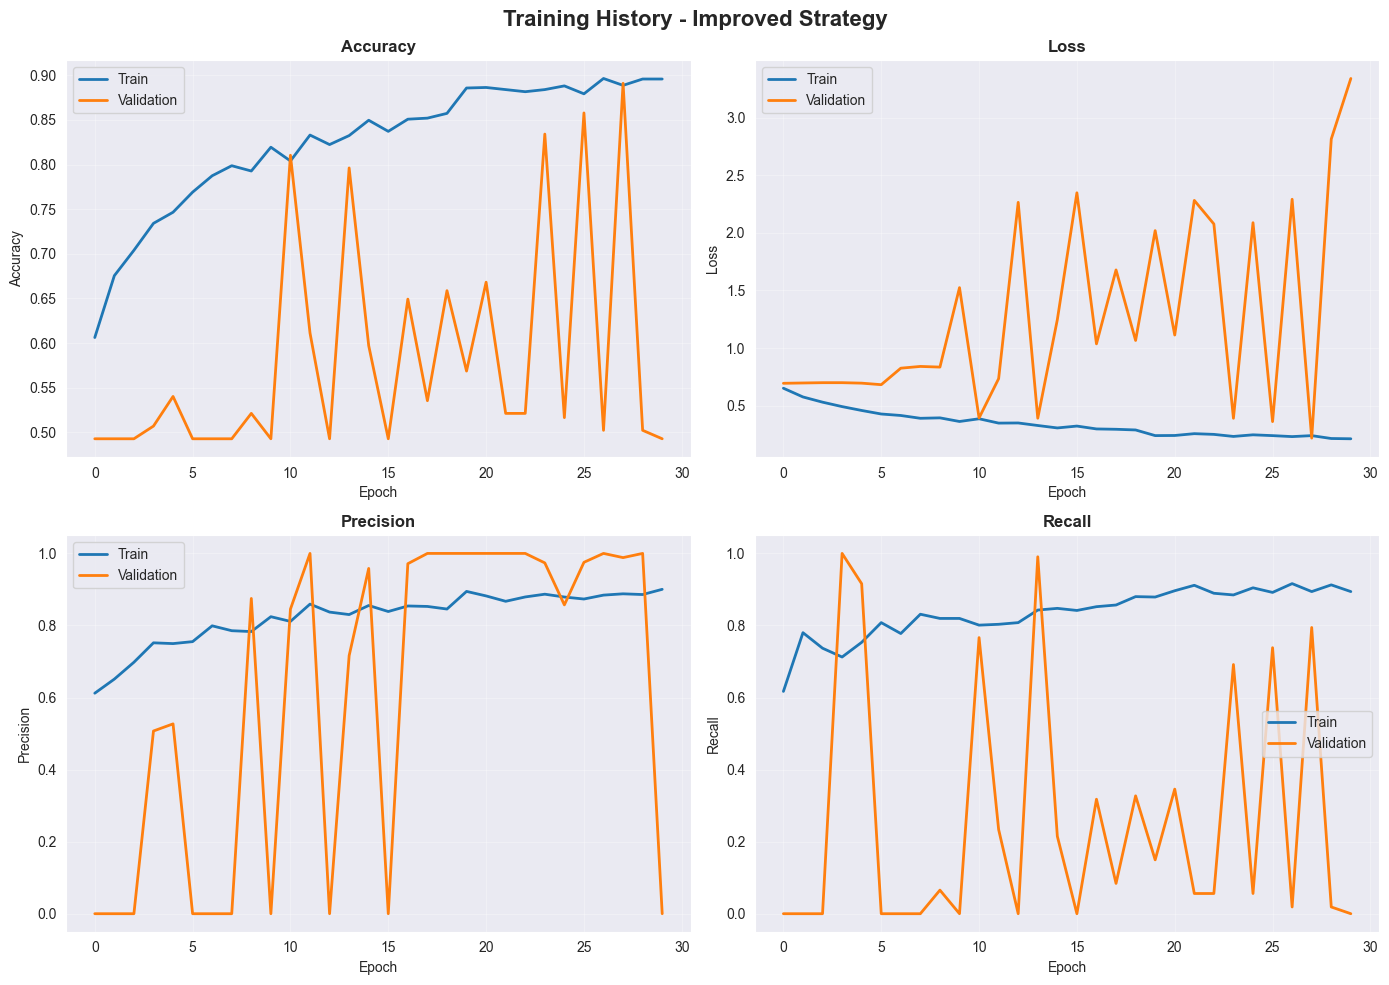

In [34]:
# ==================== SETUP CALLBACKS & TRAINING ====================
print("="*70)
print("SETUP CALLBACKS & START TRAINING")
print("="*70)

# Setup callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,  # Lebih sabar
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_cataract_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
    mode='max'
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

print("✓ Callbacks ready")
print("  • EarlyStopping: patience=10")
print("  • ReduceLR: patience=5")
print("  • Checkpoint: save best model")

# Training
print("\n" + "="*70)
print("🚀 STARTING TRAINING - Improved Strategy")
print("="*70)
print("Epochs: 30")
print("Learning Rate: 0.0001")
print("Strategy: Partial fine-tuning")
print("Preprocessing: Simple (normalize only)")
print("="*70)

print("\nStarting training...")
print("-"*70)

start_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_list,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*70)
print("✓ TRAINING COMPLETE!")
print("="*70)
print(f"Total training time: {training_time/60:.2f} minutes")

# Best results
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = max(history.history['val_accuracy'])
best_train_acc = history.history['accuracy'][best_epoch]
best_val_loss = min(history.history['val_loss'])

print(f"\n📊 BEST RESULTS:")
print("="*70)
print(f"Best Epoch: {best_epoch + 1}")
print(f"Best Train Accuracy: {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")
print(f"Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best Val Loss: {best_val_loss:.4f}")

# Check overfitting
if best_train_acc - best_val_acc > 0.1:
    print(f"\n⚠ Overfitting detected: {(best_train_acc - best_val_acc)*100:.2f}% gap")
else:
    print(f"\n✓ Good generalization: {abs(best_train_acc - best_val_acc)*100:.2f}% gap")

print("="*70)

# Plot training history
print("\n📈 Plotting training history...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History - Improved Strategy', fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].set_title('Accuracy', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].set_title('Loss', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2)
axes[1, 0].set_title('Precision', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[1, 1].set_title('Recall', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*70)

🎯 EVALUATING MODEL ON TEST SET

📦 Loading best model...
✓ Best model loaded

Running evaluation on test set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 827ms/step - accuracy: 0.8393 - auc: 0.9519 - loss: 0.3227 - precision: 0.9148 - recall: 0.7701

📊 TEST SET RESULTS
Test Accuracy:  0.8679 (86.79%)
Test Precision: 0.9348
Test Recall:    0.7963
Test AUC:       0.9646
Test Loss:      0.2805

🔮 Getting predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step  
✓ Predictions obtained (212 samples)

📈 CONFUSION MATRIX

                Predicted
              Cataract  Normal
Actual Cataract    98        6
       Normal      22       86

True Positives (TP):  86
True Negatives (TN):  98
False Positives (FP): 6
False Negatives (FN): 22

Sensitivity (Recall): 0.7963
Specificity:          0.9423

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Cataract     0.8167    0.9423    0.8750       104
      Normal     0.9348    0.7963    0.8600       108

    accuracy                   

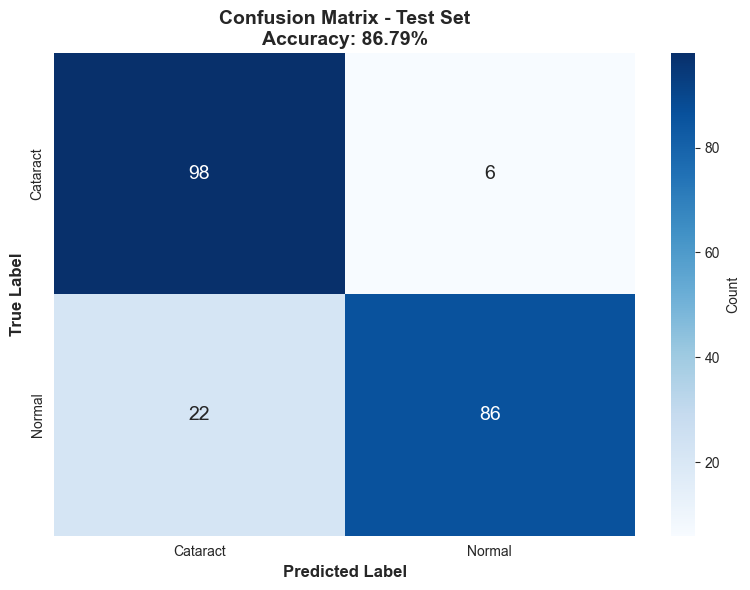


✓ EVALUATION COMPLETE!


In [35]:
# ==================== EVALUATE ON TEST SET ====================
print("="*70)
print("🎯 EVALUATING MODEL ON TEST SET")
print("="*70)

# Load best model
print("\n📦 Loading best model...")
model = keras.models.load_model('best_cataract_model_v2.keras')
print("✓ Best model loaded")

# Evaluate
print("\n" + "="*70)
print("Running evaluation on test set...")
print("="*70)

test_loss, test_acc, test_prec, test_rec, test_auc = model.evaluate(
    test_gen, 
    verbose=1
)

print("\n" + "="*70)
print("📊 TEST SET RESULTS")
print("="*70)
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Loss:      {test_loss:.4f}")
print("="*70)

# Get predictions
print("\n🔮 Getting predictions...")
test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

print(f"✓ Predictions obtained ({len(y_pred)} samples)")

# Confusion Matrix
print("\n" + "="*70)
print("📈 CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen.class_indices.keys())

print("\n                Predicted")
print("              Cataract  Normal")
print(f"Actual Cataract   {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"       Normal     {cm[1,0]:3d}      {cm[1,1]:3d}")

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives (TP):  {tp}")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

# Additional metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")

# Classification Report
print("\n" + "="*70)
print("📋 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax, annot_kws={'size': 14})

ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax.set_title(f'Confusion Matrix - Test Set\nAccuracy: {test_acc*100:.2f}%', 
             fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✓ EVALUATION COMPLETE!")
print("="*70)